# Algoritma Bellman-Ford: Shortest Path pada Jaringan Halte TransJakarta Sekitar Simpang Semanggi

---

**Mata Kuliah:** Perangkat Lunak Matematika

**Topik:** Implementasi Algoritma Shortest Path (Bellman-Ford, dibandingkan dengan Dijkstra)

---

## 1. Penjelasan Studi Kasus

### 1.1 Latar Belakang

Persoalan lintasan terpendek (*shortest path*) adalah salah satu persoalan klasik dalam teori graf dengan aplikasi luas, salah satunya pada sistem transportasi publik: menentukan rute tercepat/terdekat antar halte, antar bandara, atau antar simpul jaringan lainnya.

Dua algoritma klasik yang sering digunakan untuk persoalan ini adalah **Algoritma Dijkstra** dan **Algoritma Bellman-Ford**. Keduanya bertujuan mencari jarak terpendek dari satu simpul sumber ke seluruh simpul lain pada graf berbobot, namun berbeda dari segi strategi maupun keterbatasannya.

### 1.2 Rumusan Masalah

Diberikan sebuah graf berbobot $G = (V, E)$ yang merepresentasikan jaringan halte TransJakarta di sekitar Simpang Semanggi, dengan simpul $V$ adalah halte dan bobot sisi $E$ adalah jarak tempuh antar halte (dalam km).

Tentukan lintasan terpendek dari satu halte asal ke seluruh halte lainnya menggunakan **Algoritma Bellman-Ford**, dengan struktur representasi graf yang sama seperti yang biasa digunakan pada Algoritma Dijkstra (*adjacency list*), kemudian bandingkan hasil dan karakteristik kedua algoritma tersebut.

### 1.3 Studi Kasus: Jaringan Halte TransJakarta Sekitar Simpang Semanggi

Simpang Semanggi merupakan salah satu titik transit tersibuk TransJakarta karena dilewati beberapa koridor sekaligus:

- **Koridor 9** (Pinang Ranti - Pluit) - melewati Halte Tegal Parang, Simpang Kuningan, Denpasar, Widya Chandra, **Semanggi**, Senayan, Petamburan, dst.
- **Koridor 6B** (Ragunan - Balai Kota via Semanggi) - melewati Halte Mampang Prapatan, **Semanggi**, Dukuh Atas, Tosari, Bundaran HI, Kebon Sirih, dst.
- Halte Semanggi juga terhubung dengan **Halte Bendungan Hilir** (Koridor 1) melalui Jembatan Penyeberangan Orang (JPO) Komdak sepanjang **574 meter**, transit terpanjang di DKI Jakarta.

Data nama halte, urutan koridor, dan jarak transit 574 m diambil dari referensi resmi/publik berikut:

- [Halte Transjakarta Semanggi - Wikipedia](https://id.wikipedia.org/wiki/Halte_Transjakarta_Semanggi)
- [Koridor 9 TransJakarta: Pinang Ranti - Pluit](https://blog.bankmega.com/koridor-9-transjakarta/)
- [Rute 6B TransJakarta: Ragunan-Balai Kota via Semanggi](https://blog.bankmega.com/rute-6b-transjakarta-ragunan-balai-kota-via-semanggi/)
- [Transjakarta - Rute Resmi](https://transjakarta.co.id/rute)

> **Catatan metodologi data:** TransJakarta tidak mempublikasikan matriks jarak antar-halte secara terbuka. Jarak antar-halte pada studi kasus ini diestimasi dari panjang total koridor resmi dibagi jumlah halte (Koridor 9 kurang lebih 24,5 km / 26 halte atau sekitar 0,94 km per segmen; Koridor 6 kurang lebih 13,3 km / 19 halte atau sekitar 0,7 km per segmen), kecuali jarak transit Semanggi-Bendungan Hilir yang menggunakan data resmi (574 m). Nama halte dan urutan koneksi adalah data nyata, sedangkan jarak presisi merupakan estimasi.

### 1.4 Mengapa Bellman-Ford?

Arahan tugas meminta struktur graf mengikuti gaya Dijkstra (*adjacency list*), namun algoritma utama yang diimplementasikan adalah **Bellman-Ford**. Alasan Bellman-Ford tetap layak dipelajari meskipun Dijkstra lebih cepat pada graf berbobot non-negatif:

| Aspek | Dijkstra | Bellman-Ford |
|---|---|---|
| Bobot negatif | Tidak didukung (hasil bisa salah) | Didukung |
| Deteksi siklus negatif | Tidak bisa | Bisa |
| Kompleksitas | $O((V+E)\log V)$ dengan *priority queue* | $O(V \cdot E)$ |
| Struktur data | *Priority queue* (heap) | Relaksasi semua sisi berulang |
| Cocok untuk | Graf jarak/waktu tempuh transportasi (bobot >= 0) | Graf dengan kemungkinan bobot negatif (misal: subsidi/insentif biaya) |

Pada bagian akhir notebook ini, kedua algoritma dijalankan pada graf jaringan halte nyata (bobot non-negatif, hasil identik), kemudian diberikan **ilustrasi abstrak terpisah** dengan bobot negatif untuk menunjukkan kasus di mana Dijkstra gagal memberikan hasil benar sementara Bellman-Ford tetap benar.


## 2. Landasan Teori

### 2.1 Representasi Graf Berbobot

Graf direpresentasikan sebagai ***adjacency list*** berbentuk *dictionary* bersarang (gaya yang umum dipakai pada implementasi Dijkstra):
    
```
graf = {
    "A": {"B": 5, "C": 2},
    "B": {"A": 5},
    "C": {"A": 2},
    ...
}
```

`graf[u][v] = w` berarti terdapat sisi dari simpul $u$ ke simpul $v$ dengan bobot $w$. Karena rute bus berlaku dua arah pada koridor yang sama, graf pada studi kasus jaringan halte bersifat **tidak berarah** (setiap sisi ditambahkan ke kedua arah).

### 2.2 Algoritma Dijkstra (Ringkasan)

Dijkstra bekerja secara *greedy*: pada setiap langkah, ambil simpul belum-final dengan jarak tentatif terkecil (menggunakan *min-heap*), tetapkan sebagai final, lalu lakukan *relaksasi* pada seluruh tetangganya.

$$\text{jika } d[u] + w(u,v) < d[v] \implies d[v] \leftarrow d[u] + w(u,v)$$

Begitu sebuah simpul ditetapkan final, jaraknya **tidak akan diproses ulang sebagai simpul aktif** - inilah sebabnya Dijkstra bisa gagal jika ada bobot negatif: simpul tetangga yang sudah diproses bisa saja memiliki jalur lebih murah lewat sisi negatif yang baru ditemukan setelahnya.

### 2.3 Algoritma Bellman-Ford

Bellman-Ford tidak bekerja secara *greedy*, melainkan melakukan **relaksasi seluruh sisi sebanyak $|V|-1$ kali** secara berulang:

| Langkah | Deskripsi |
|:---:|:---|
| 1 | Inisialisasi $d[\text{asal}] = 0$, $d[v] = \infty$ untuk simpul lain |
| 2 | Ulangi sebanyak $|V| - 1$ kali: untuk setiap sisi $(u,v,w)$, jika $d[u]+w < d[v]$ maka perbarui $d[v]$ |
| 3 | Lakukan satu kali pengecekan tambahan: jika masih ada sisi yang bisa direlaksasi, berarti terdapat **siklus berbobot negatif** |

**Mengapa $|V|-1$ iterasi cukup?** Lintasan terpendek pada graf tanpa siklus negatif paling banyak melalui $|V|-1$ sisi (karena tidak boleh mengulang simpul). Setiap iterasi penuh menjamin informasi jarak menjalar sejauh minimal satu sisi tambahan, sehingga setelah $|V|-1$ iterasi seluruh lintasan terpendek sudah ditemukan.

### 2.4 Kompleksitas

| Algoritma | Waktu | Ruang | Bobot Negatif |
|---|---|---|---|
| Dijkstra (heap) | $O((V+E)\log V)$ | $O(V)$ | Tidak valid |
| Bellman-Ford | $O(V \cdot E)$ | $O(V)$ | Valid + deteksi siklus negatif |

Pada graf jaringan TransJakarta yang relatif kecil ($V=13$, $E=13$), perbedaan performa keduanya tidak signifikan - namun pada graf besar, Dijkstra jauh lebih efisien **selama bobot tidak negatif**.

## 3. Source Code

| Fungsi | Tanggung Jawab |
|---|---|
| `buat_graf_tj()` | Membangun *adjacency list* jaringan halte TransJakarta sekitar Semanggi |
| `dijkstra(graf, asal)` | Mencari lintasan terpendek dari `asal` ke semua simpul menggunakan Dijkstra (*priority queue*) |
| `bellman_ford(graf, asal)` | Mencari lintasan terpendek dari `asal` ke semua simpul menggunakan Bellman-Ford (relaksasi sisi) |
| `rekonstruksi_jalur(pendahulu, asal, tujuan)` | Menyusun ulang rute lengkap dari tabel *predecessor* |
| `tampilkan_hasil(...)` | Mencetak tabel jarak & rute dari satu halte asal ke seluruh halte lain |
| `plot_graf(...)` | Memvisualisasikan jaringan halte dan menyorot rute terpendek tertentu |

### 3.1 Import Library

In [11]:
import heapq
import math
import matplotlib.pyplot as plt

### 3.2 Representasi Graf - `buat_graf_tj()`

Berikut representasi graf jaringan halte berdasarkan data pada bagian 1.3:

| Sisi (Halte A - Halte B) | Bobot (km) | Koridor / Keterangan |
|---|---|---|
| Tegal Parang - Simpang Kuningan | 0.90 | Koridor 9 |
| Simpang Kuningan - Denpasar | 0.85 | Koridor 9 |
| Denpasar - Widya Chandra | 0.95 | Koridor 9 |
| Widya Chandra - Semanggi | 1.00 | Koridor 9 |
| Semanggi - Senayan | 1.10 | Koridor 9 |
| Senayan - Petamburan | 1.05 | Koridor 9 |
| Mampang Prapatan - Semanggi | 1.20 | Koridor 6B |
| Semanggi - Dukuh Atas | 1.30 | Koridor 6B |
| Dukuh Atas - Tosari | 0.50 | Koridor 6B |
| Tosari - Bundaran HI | 0.40 | Koridor 6B |
| Bundaran HI - Kebon Sirih | 0.60 | Koridor 6B |
| Semanggi - Bendungan Hilir | 0.574 | Transit JPO Komdak (data resmi) |
| Dukuh Atas - Bendungan Hilir | 0.40 | Estimasi; kedua halte berada di kawasan simpul transit terintegrasi Dukuh Atas |

Sisi terakhir (Dukuh Atas - Bendungan Hilir) ditambahkan agar graf memiliki **lebih dari satu kemungkinan rute** antar sebagian halte (graf tidak murni berbentuk pohon), sehingga peran algoritma *shortest path* lebih terlihat jelas.

In [12]:
def buat_graf_tj():
    graf = {
        "Tegal Parang": {}, "Simpang Kuningan": {}, "Denpasar": {}, "Widya Chandra": {},
        "Semanggi": {}, "Senayan": {}, "Petamburan": {}, "Mampang Prapatan": {},
        "Dukuh Atas": {}, "Tosari": {}, "Bundaran HI": {}, "Kebon Sirih": {},
        "Bendungan Hilir": {},
    }

    def tambah_sisi(a, b, jarak):
        # Rute bus berlaku dua arah pada koridor yang sama
        graf[a][b] = jarak
        graf[b][a] = jarak

    tambah_sisi("Tegal Parang", "Simpang Kuningan", 0.90)
    tambah_sisi("Simpang Kuningan", "Denpasar", 0.85)
    tambah_sisi("Denpasar", "Widya Chandra", 0.95)
    tambah_sisi("Widya Chandra", "Semanggi", 1.00)
    tambah_sisi("Semanggi", "Senayan", 1.10)
    tambah_sisi("Senayan", "Petamburan", 1.05)
    tambah_sisi("Mampang Prapatan", "Semanggi", 1.20)
    tambah_sisi("Semanggi", "Dukuh Atas", 1.30)
    tambah_sisi("Dukuh Atas", "Tosari", 0.50)
    tambah_sisi("Tosari", "Bundaran HI", 0.40)
    tambah_sisi("Bundaran HI", "Kebon Sirih", 0.60)
    tambah_sisi("Semanggi", "Bendungan Hilir", 0.574)
    tambah_sisi("Dukuh Atas", "Bendungan Hilir", 0.40)

    return graf

### 3.3 Algoritma Dijkstra

Implementasi standar menggunakan *min-heap* (`heapq`) dengan strategi *lazy deletion*: entri basi pada heap cukup dilewati (`continue`) saat simpul yang sama muncul kembali dalam keadaan sudah final.

In [13]:
def dijkstra(graf, asal):
    jarak = {simpul: math.inf for simpul in graf}
    pendahulu = {simpul: None for simpul in graf}
    jarak[asal] = 0

    antrian = [(0, asal)]
    dikunjungi = set()

    while antrian:
        d_sekarang, simpul = heapq.heappop(antrian)
        if simpul in dikunjungi:
            continue
        dikunjungi.add(simpul)

        for tetangga, bobot in graf[simpul].items():
            d_baru = d_sekarang + bobot
            if d_baru < jarak[tetangga]:
                jarak[tetangga] = d_baru
                pendahulu[tetangga] = simpul
                heapq.heappush(antrian, (d_baru, tetangga))

    return jarak, pendahulu

### 3.4 Algoritma Bellman-Ford

Menggunakan struktur graf yang identik dengan `dijkstra()` (*adjacency list*), namun strateginya berbeda: alih-alih memproses simpul secara *greedy* berdasarkan jarak terkecil, seluruh sisi direlaksasi berulang sebanyak $|V|-1$ kali, lalu dilakukan satu pengecekan tambahan untuk mendeteksi siklus negatif.

In [14]:
def bellman_ford(graf, asal):
    simpul_list = list(graf)
    jarak = {simpul: math.inf for simpul in simpul_list}
    pendahulu = {simpul: None for simpul in simpul_list}
    jarak[asal] = 0

    daftar_sisi = [(u, v, w) for u in graf for v, w in graf[u].items()]

    for _ in range(len(simpul_list) - 1):
        ada_perubahan = False
        for u, v, w in daftar_sisi:
            if jarak[u] + w < jarak[v]:
                jarak[v] = jarak[u] + w
                pendahulu[v] = u
                ada_perubahan = True
        if not ada_perubahan:
            break

    siklus_negatif = False
    for u, v, w in daftar_sisi:
        if jarak[u] + w < jarak[v]:
            siklus_negatif = True
            break

    return jarak, pendahulu, siklus_negatif

### 3.5 Rekonstruksi Jalur dan Tampilan Hasil

In [15]:
def rekonstruksi_jalur(pendahulu, asal, tujuan):
    jalur = []
    simpul = tujuan
    while simpul is not None:
        jalur.append(simpul)
        if simpul == asal:
            break
        simpul = pendahulu[simpul]
    jalur.reverse()
    if jalur[0] != asal:
        return None
    return jalur


def tampilkan_hasil(graf, asal, jarak, pendahulu, judul="Hasil"):
    print(f"\n{judul} - titik asal: {asal}")
    print(f"{'Halte Tujuan':<20}{'Jarak (km)':<14}{'Rute'}")
    print("-" * 80)
    for tujuan in graf:
        if tujuan == asal:
            continue
        jalur = rekonstruksi_jalur(pendahulu, asal, tujuan)
        rute_str = " -> ".join(jalur) if jalur else "-"
        jarak_str = f"{jarak[tujuan]:.3f}" if jarak[tujuan] != math.inf else "tak terhubung"
        print(f"{tujuan:<20}{jarak_str:<14}{rute_str}")

### 3.6 Visualisasi Graf

Posisi setiap halte pada `POSISI_HALTE` bersifat **ilustratif** untuk kejelasan tampilan (bukan koordinat geografis presisi), disusun agar mencerminkan struktur dua koridor yang bertemu di Semanggi.

In [16]:
POSISI_HALTE = {
    "Tegal Parang": (-3.0, 1.0),
    "Simpang Kuningan": (-2.3, 0.7),
    "Denpasar": (-1.6, 0.4),
    "Widya Chandra": (-0.9, 0.1),
    "Semanggi": (0.0, 0.0),
    "Senayan": (0.9, 0.3),
    "Petamburan": (1.8, 0.6),
    "Mampang Prapatan": (-0.6, -1.2),
    "Dukuh Atas": (0.6, -1.0),
    "Tosari": (1.1, -1.7),
    "Bundaran HI": (1.6, -2.4),
    "Kebon Sirih": (2.1, -3.1),
    "Bendungan Hilir": (-0.2, -0.9),
}


def plot_graf(graf, jalur_highlight=None, judul="Jaringan Halte TransJakarta Sekitar Semanggi"):
    fig, ax = plt.subplots(figsize=(11, 8))

    sisi_tergambar = set()
    for u in graf:
        for v, w in graf[u].items():
            kunci = frozenset((u, v))
            if kunci in sisi_tergambar:
                continue
            sisi_tergambar.add(kunci)
            x1, y1 = POSISI_HALTE[u]
            x2, y2 = POSISI_HALTE[v]
            ax.plot([x1, x2], [y1, y2], color="#b0b0b0", linewidth=1.5, zorder=1)
            xm, ym = (x1 + x2) / 2, (y1 + y2) / 2
            ax.text(xm, ym, f"{w:.2f}", fontsize=7, color="#555555",
                    ha="center", va="center", backgroundcolor="white")

    if jalur_highlight and len(jalur_highlight) > 1:
        for u, v in zip(jalur_highlight[:-1], jalur_highlight[1:]):
            x1, y1 = POSISI_HALTE[u]
            x2, y2 = POSISI_HALTE[v]
            ax.plot([x1, x2], [y1, y2], color="#d62728", linewidth=3.5, zorder=2)

    highlight_set = set(jalur_highlight) if jalur_highlight else set()
    for simpul, (x, y) in POSISI_HALTE.items():
        warna = "#ffd1a3" if simpul in highlight_set else "#cce5ff"
        tepi = "#d62728" if simpul in highlight_set else "#1a6bbf"
        ax.scatter(x, y, s=900, color=warna, edgecolors=tepi, linewidths=1.8, zorder=3)
        ax.text(x, y - 0.18, simpul, fontsize=8, ha="center", va="top",
                fontweight="bold", zorder=4)

    ax.set_title(judul, fontsize=13, fontweight="bold", pad=15)
    ax.axis("off")
    ax.set_aspect("equal")
    plt.tight_layout()
    plt.show()

## 4. Hasil

### 4.1 Visualisasi Jaringan Halte

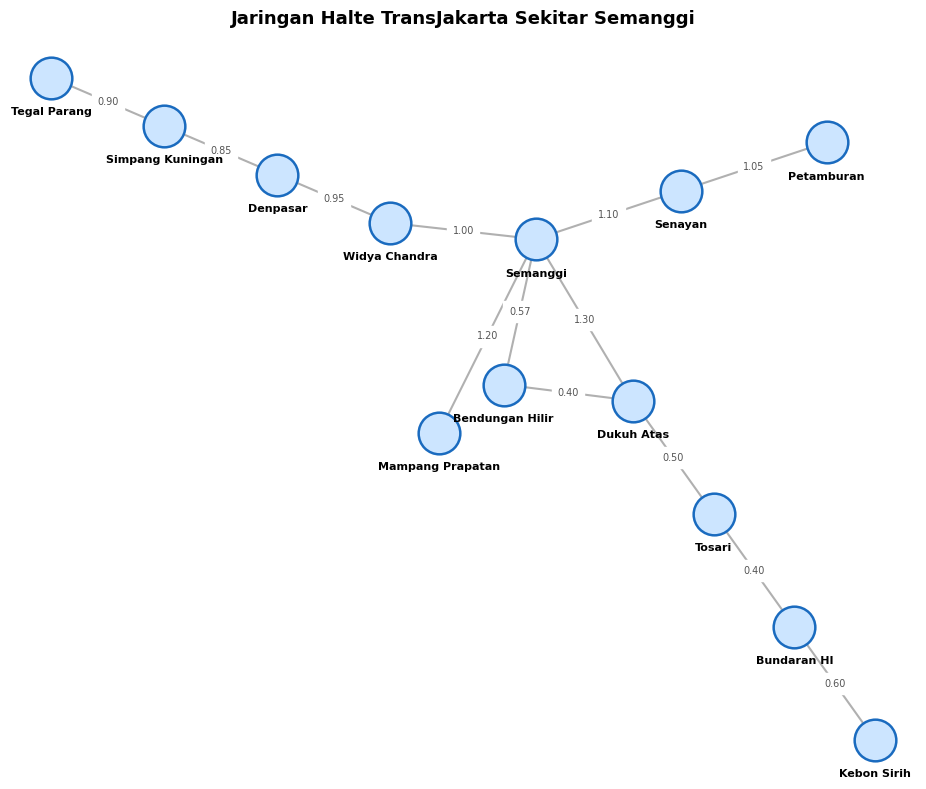

In [17]:
graf = buat_graf_tj()
plot_graf(graf)

### 4.2 Lintasan Terpendek dari Halte Tegal Parang (Dijkstra vs Bellman-Ford)

Karena graf jaringan halte ini berbobot **non-negatif**, kedua algoritma seharusnya menghasilkan jarak dan rute yang identik.

In [18]:
asal = "Tegal Parang"

jarak_dij, pendahulu_dij = dijkstra(graf, asal)
jarak_bf, pendahulu_bf, siklus_negatif = bellman_ford(graf, asal)

tampilkan_hasil(graf, asal, jarak_dij, pendahulu_dij, judul="Dijkstra")
tampilkan_hasil(graf, asal, jarak_bf, pendahulu_bf, judul="Bellman-Ford")

selisih_maks = max(abs(jarak_dij[s] - jarak_bf[s]) for s in graf)
print(f"\nSiklus negatif terdeteksi: {siklus_negatif}")
print(f"Selisih maksimum hasil Dijkstra vs Bellman-Ford: {selisih_maks:.10f} "
      f"(seharusnya 0, karena tidak ada bobot negatif)")


Dijkstra - titik asal: Tegal Parang
Halte Tujuan        Jarak (km)    Rute
--------------------------------------------------------------------------------
Simpang Kuningan    0.900         Tegal Parang -> Simpang Kuningan
Denpasar            1.750         Tegal Parang -> Simpang Kuningan -> Denpasar
Widya Chandra       2.700         Tegal Parang -> Simpang Kuningan -> Denpasar -> Widya Chandra
Semanggi            3.700         Tegal Parang -> Simpang Kuningan -> Denpasar -> Widya Chandra -> Semanggi
Senayan             4.800         Tegal Parang -> Simpang Kuningan -> Denpasar -> Widya Chandra -> Semanggi -> Senayan
Petamburan          5.850         Tegal Parang -> Simpang Kuningan -> Denpasar -> Widya Chandra -> Semanggi -> Senayan -> Petamburan
Mampang Prapatan    4.900         Tegal Parang -> Simpang Kuningan -> Denpasar -> Widya Chandra -> Semanggi -> Mampang Prapatan
Dukuh Atas          4.674         Tegal Parang -> Simpang Kuningan -> Denpasar -> Widya Chandra -> Semanggi -> Be

### 4.3 Visualisasi Rute Terpendek (Contoh: Tegal Parang -> Kebon Sirih)

Rute terpendek Tegal Parang -> Kebon Sirih: Tegal Parang -> Simpang Kuningan -> Denpasar -> Widya Chandra -> Semanggi -> Bendungan Hilir -> Dukuh Atas -> Tosari -> Bundaran HI -> Kebon Sirih
Total jarak: 6.174 km


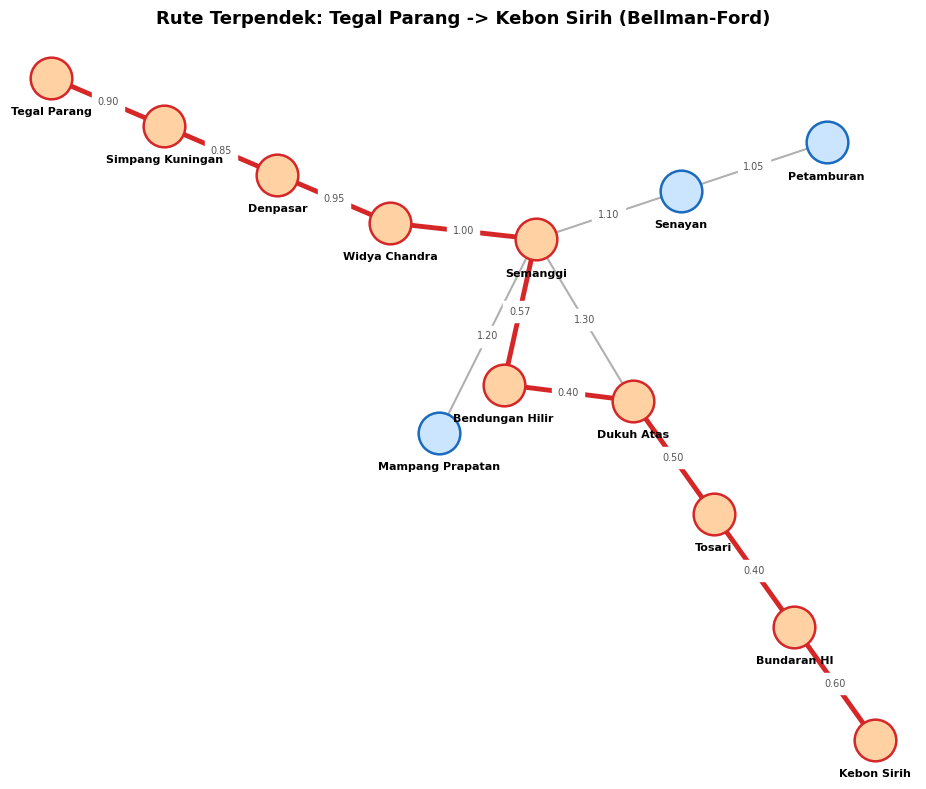

In [19]:
tujuan = "Kebon Sirih"
jalur = rekonstruksi_jalur(pendahulu_bf, asal, tujuan)

print(f"Rute terpendek {asal} -> {tujuan}: {' -> '.join(jalur)}")
print(f"Total jarak: {jarak_bf[tujuan]:.3f} km")

plot_graf(graf, jalur_highlight=jalur,
          judul=f"Rute Terpendek: {asal} -> {tujuan} (Bellman-Ford)")

### 4.4 Ilustrasi: Mengapa Dijkstra Bisa Gagal pada Bobot Negatif

Graf jaringan TransJakarta di atas tidak memiliki bobot negatif sehingga belum menunjukkan keunggulan unik Bellman-Ford. Bagian ini menggunakan **graf arah (directed) abstrak buatan sendiri** - bukan data transportasi nyata - semata-mata untuk mendemonstrasikan kasus klasik di mana Dijkstra memberikan hasil yang **salah**.

Graf: $A \to X$ (1), $A \to Y$ (2), $X \to Z$ (5), $Y \to X$ (-100).

Lintasan terpendek sebenarnya dari $A$ ke $X$ adalah lewat $Y$: $A \to Y \to X = 2 + (-100) = -98$, bukan lewat sisi langsung $A \to X = 1$. Akibatnya $Z$ yang bergantung pada $X$ juga ikut salah jika $X$ sudah final sebelum koreksi ditemukan.

In [20]:
def graf_abstrak_demo():
    # Graf arah abstrak, BUKAN data transportasi nyata.
    return {
        "A": {"X": 1, "Y": 2},
        "X": {"Z": 5},
        "Y": {"X": -100},
        "Z": {},
    }


graf_demo = graf_abstrak_demo()

jarak_dij_demo, _ = dijkstra(graf_demo, "A")
jarak_bf_demo, _, siklus_negatif_demo = bellman_ford(graf_demo, "A")

print("Hasil Dijkstra       :", jarak_dij_demo)
print("Hasil Bellman-Ford    :", jarak_bf_demo)
print("Siklus negatif terdeteksi:", siklus_negatif_demo)

print("\nPerbedaan kritis pada simpul Z (bergantung pada X):")
print(f"  Dijkstra      -> d(Z) = {jarak_dij_demo['Z']}  "
      f"(SALAH - Z sudah direlaksasi memakai d(X)=1 sebelum X dikoreksi ke -98)")
print(f"  Bellman-Ford  -> d(Z) = {jarak_bf_demo['Z']}  "
      f"(BENAR - lintasan: A -> Y -> X -> Z = 2 - 100 + 5 = -93)")

Hasil Dijkstra       : {'A': 0, 'X': -98, 'Y': 2, 'Z': 6}
Hasil Bellman-Ford    : {'A': 0, 'X': -98, 'Y': 2, 'Z': -93}
Siklus negatif terdeteksi: False

Perbedaan kritis pada simpul Z (bergantung pada X):
  Dijkstra      -> d(Z) = 6  (SALAH - Z sudah direlaksasi memakai d(X)=1 sebelum X dikoreksi ke -98)
  Bellman-Ford  -> d(Z) = -93  (BENAR - lintasan: A -> Y -> X -> Z = 2 - 100 + 5 = -93)


## 5. Kesimpulan

Studi kasus jaringan halte TransJakarta sekitar Simpang Semanggi berhasil mendemonstrasikan implementasi **Algoritma Bellman-Ford** untuk persoalan lintasan terpendek, dengan poin-poin utama:

1. **Representasi graf konsisten dengan gaya Dijkstra** - *adjacency list* berbentuk `dict of dict` memudahkan kedua algoritma berbagi struktur data yang sama, sehingga perbandingan hasil maupun kompleksitas menjadi adil (*apple-to-apple*).
2. **Pada graf transportasi nyata (bobot non-negatif)**, Bellman-Ford dan Dijkstra menghasilkan jarak dan rute yang **identik** - keduanya valid digunakan, namun Dijkstra lebih efisien ($O((V+E)\log V)$ dibanding $O(V \cdot E)$).
3. **Keunggulan unik Bellman-Ford** baru terlihat pada graf berbobot negatif: ilustrasi abstrak menunjukkan Dijkstra dapat memberikan jarak yang **salah** karena sifat *greedy*-nya (simpul yang sudah final tidak diproses ulang sebagai simpul aktif), sedangkan Bellman-Ford tetap memberikan hasil yang benar karena melakukan relaksasi berulang terhadap seluruh sisi.
4. **Kemampuan deteksi siklus negatif** pada Bellman-Ford (langkah relaksasi tambahan setelah $|V|-1$ iterasi) merupakan kapabilitas yang sama sekali tidak dimiliki Dijkstra - berguna misalnya untuk mendeteksi inkonsistensi pada model biaya transportasi yang melibatkan insentif atau subsidi.
5. **Studi kasus Simpang Semanggi** menunjukkan bagaimana data publik (urutan halte, panjang koridor, jarak transit resmi) dapat dipetakan menjadi graf berbobot yang realistis untuk persoalan optimasi rute transportasi publik di dunia nyata.